## 1. Install Dependencies

In [1]:
# Run this first — only need to run once
!pip install pymupdf sentence-transformers faiss-cpu Pillow wandb python-dotenv pyyaml

## 2. Imports & Path Setup

In [2]:
import fitz  # PyMuPDF
import os
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Setup paths
BASE_DIR = Path("..") 
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
IMAGE_DIR = PROCESSED_DIR / "images"

# Create dirs if not exist
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print(" Imports done")
print(f" Raw data folder: {RAW_DIR}")
print(f" Processed folder: {PROCESSED_DIR}")

 Imports done
 Raw data folder: ..\data\raw
 Processed folder: ..\data\processed


## 3. Discover PDFs

In [3]:
# List all PDFs in raw folder
pdfs = list(RAW_DIR.glob("*.pdf"))
print(f"Found {len(pdfs)} PDF(s):\n")
for pdf in pdfs:
    print(f"   {pdf.name}")

if len(pdfs) == 0:
    print("    No PDFs found! Add some PDFs to data/raw/ folder first")

Found 5 PDF(s):

   Sample_1.pdf
   Sample_2.pdf
   Sample_3.pdf
   Sample_4.pdf
   Sample_5.pdf


## 4. Analyze PDFs
Detect whether each PDF is **fully digital**, **fully scanned**, or **mixed**.
- Digital pages → text extraction via PyMuPDF
- Scanned pages → render as image → CLIP embeddings

In [4]:
def analyze_pdf(pdf_path):
    """Detect if PDF is scanned, digital, or mixed"""
    doc = fitz.open(pdf_path)
    
    digital_pages = []
    scanned_pages = []
    
    for page_num, page in enumerate(doc):
        text = page.get_text("text").strip()
        
        if text and len(text) > 50:
            digital_pages.append({
                "page": page_num,
                "text": text,
                "word_count": len(text.split()),
                "type": "digital"
            })
        else:
            scanned_pages.append({
                "page": page_num,
                "type": "scanned"
            })
    
    doc.close()
    
    total = len(digital_pages) + len(scanned_pages)
    if len(scanned_pages) == 0:
        pdf_type = "fully_digital"
    elif len(digital_pages) == 0:
        pdf_type = "fully_scanned"
    else:
        pdf_type = "mixed"
    
    return {
        "name": Path(pdf_path).name,
        "total_pages": total,
        "digital_pages": len(digital_pages),
        "scanned_pages": len(scanned_pages),
        "pdf_type": pdf_type,
        "text_data": digital_pages,
        "scanned_page_nums": [p["page"] for p in scanned_pages]
    }

# Analyze ALL PDFs
print(" Analyzing all PDFs...\n")
dataset = {}

for pdf_path in pdfs:
    result = analyze_pdf(pdf_path)
    dataset[pdf_path.name] = result
    
    print(f" {result['name']}")
    print(f"   Type            : {result['pdf_type'].upper()}")
    print(f"   Total pages     : {result['total_pages']}")
    print(f"   Digital pages   : {result['digital_pages']} ← text extraction")
    print(f"   Scanned pages   : {result['scanned_pages']} ← image/OCR pipeline")
    print()

 Analyzing all PDFs...

 Sample_1.pdf
   Type            : FULLY_SCANNED
   Total pages     : 21
   Digital pages   : 0 ← text extraction
   Scanned pages   : 21 ← image/OCR pipeline

 Sample_2.pdf
   Type            : FULLY_DIGITAL
   Total pages     : 22
   Digital pages   : 22 ← text extraction
   Scanned pages   : 0 ← image/OCR pipeline

 Sample_3.pdf
   Type            : FULLY_DIGITAL
   Total pages     : 17
   Digital pages   : 17 ← text extraction
   Scanned pages   : 0 ← image/OCR pipeline

 Sample_4.pdf
   Type            : FULLY_DIGITAL
   Total pages     : 28
   Digital pages   : 28 ← text extraction
   Scanned pages   : 0 ← image/OCR pipeline

 Sample_5.pdf
   Type            : FULLY_DIGITAL
   Total pages     : 26
   Digital pages   : 26 ← text extraction
   Scanned pages   : 0 ← image/OCR pipeline



## 5. Visualize Sample Pages
Quick sanity check — render the first few pages of the first PDF to see what we're working with.

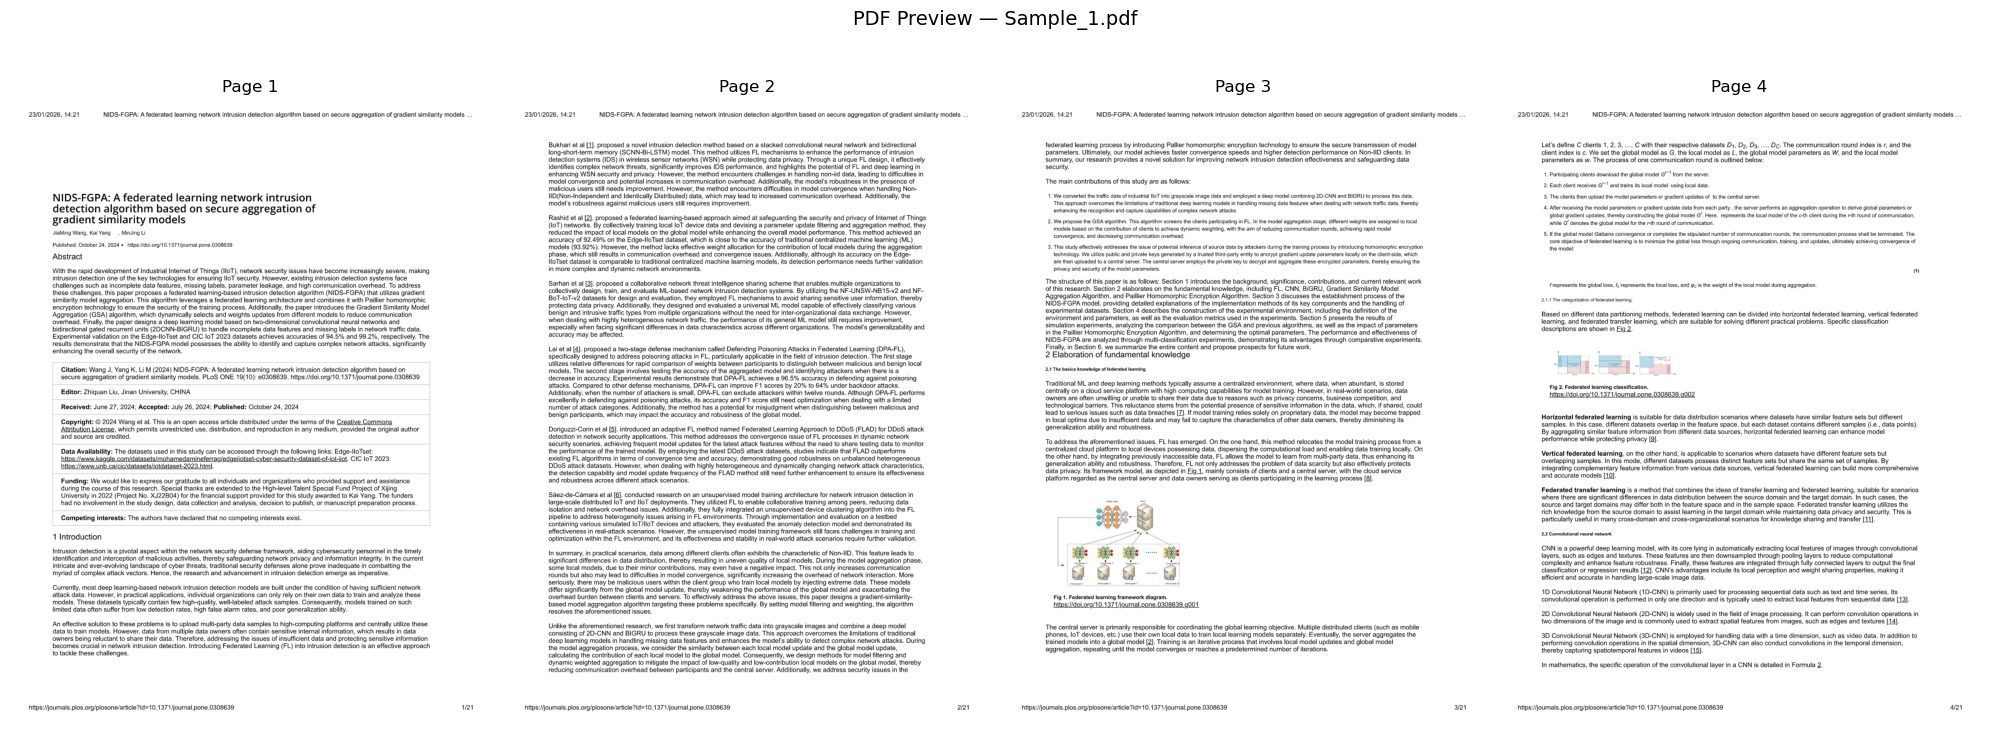

 Rendered 4 pages as images


In [5]:
def show_pdf_pages(pdf_path, max_pages=4):
    doc = fitz.open(pdf_path)
    total = min(max_pages, len(doc))
    
    fig, axes = plt.subplots(1, total, figsize=(5 * total, 8))
    if total == 1:
        axes = [axes]
    
    for i in range(total):
        page = doc[i]
        mat = fitz.Matrix(1.5, 1.5)  # zoom factor
        pix = page.get_pixmap(matrix=mat)
        img_path = IMAGE_DIR / f"page_render_{i}.png"
        pix.save(str(img_path))
        
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Page {i+1}")
        axes[i].axis("off")
    
    doc.close()
    plt.suptitle(f"PDF Preview — {Path(pdf_path).name}", fontsize=14)
    plt.tight_layout()
    plt.show()
    print(f" Rendered {total} pages as images")

if pdfs:
    show_pdf_pages(pdfs[0])

## 6. Process All PDFs → Chunks
Routes each page to the correct pipeline:
- **Digital pages** → extract text directly
- **Scanned pages** → render as PNG at 150 DPI

In [6]:
def process_all_pdfs(pdfs, dataset, image_dir):
    all_chunks = []
    
    for pdf_path in pdfs:
        pdf_name = pdf_path.name
        info = dataset[pdf_name]
        doc = fitz.open(pdf_path)
        
        print(f"\n{'='*50}")
        print(f"Processing: {pdf_name} [{info['pdf_type'].upper()}]")
        print(f"{'='*50}")
        
        # Create subfolder per PDF
        pdf_img_dir = image_dir / Path(pdf_path).stem
        pdf_img_dir.mkdir(parents=True, exist_ok=True)
        
        for page_num in range(info["total_pages"]):
            page = doc[page_num]
            
            if page_num not in info["scanned_page_nums"]:
                #  DIGITAL PAGE — extract text
                text = page.get_text("text").strip()
                all_chunks.append({
                    "source": pdf_name,
                    "page": page_num,
                    "type": "text",
                    "content": text,
                    "image_path": None
                })
                print(f"    Page {page_num+1:02d} → text extracted ({len(text.split())} words)")
            
            else:
                #  SCANNED PAGE — render as image
                mat = fitz.Matrix(150/72, 150/72)
                pix = page.get_pixmap(matrix=mat)
                img_path = pdf_img_dir / f"page_{page_num:03d}.png"
                pix.save(str(img_path))
                
                all_chunks.append({
                    "source": pdf_name,
                    "page": page_num,
                    "type": "image",
                    "content": None,
                    "image_path": str(img_path)
                })
                print(f"     Page {page_num+1:02d} → saved as image")
        
        doc.close()
    
    return all_chunks

# Run it
all_chunks = process_all_pdfs(pdfs, dataset, IMAGE_DIR)


Processing: Sample_1.pdf [FULLY_SCANNED]
     Page 01 → saved as image
     Page 02 → saved as image
     Page 03 → saved as image
     Page 04 → saved as image
     Page 05 → saved as image
     Page 06 → saved as image
     Page 07 → saved as image
     Page 08 → saved as image
     Page 09 → saved as image
     Page 10 → saved as image
     Page 11 → saved as image
     Page 12 → saved as image
     Page 13 → saved as image
     Page 14 → saved as image
     Page 15 → saved as image
     Page 16 → saved as image
     Page 17 → saved as image
     Page 18 → saved as image
     Page 19 → saved as image
     Page 20 → saved as image
     Page 21 → saved as image

Processing: Sample_2.pdf [FULLY_DIGITAL]
    Page 01 → text extracted (313 words)
    Page 02 → text extracted (481 words)
    Page 03 → text extracted (278 words)
    Page 04 → text extracted (519 words)
    Page 05 → text extracted (250 words)
    Page 06 → text extracted (338 words)
    Page 07 → text extracted (182 words)

## 7. Final Dataset Overview
Summary of what was extracted — used as input to Notebook 02.

In [7]:
text_chunks = [c for c in all_chunks if c["type"] == "text"]
image_chunks = [c for c in all_chunks if c["type"] == "image"]

print("\n" + "="*50)
print(" FINAL DATASET OVERVIEW")
print("="*50)
print(f"Total PDFs processed  : {len(pdfs)}")
print(f"Total chunks          : {len(all_chunks)}")
print(f"    Text pages    : {len(text_chunks)}")
print(f"     Image pages   : {len(image_chunks)}")
print()
print("Pipeline routing:")
print("  Text pages  → sentence-transformers → FAISS")
print("  Image pages → CLIP embeddings      → FAISS")
print()

# Save experiment log
log = {
    "total_pdfs": len(pdfs),
    "total_chunks": len(all_chunks),
    "text_chunks": len(text_chunks),
    "image_chunks": len(image_chunks),
    "pdfs": {
        name: {
            "type": info["pdf_type"],
            "total_pages": info["total_pages"],
            "digital": info["digital_pages"],
            "scanned": info["scanned_pages"]
        }
        for name, info in dataset.items()
    }
}

log_path = BASE_DIR / "experiments" / "01_exploration_summary.json"
with open(log_path, "w") as f:
    json.dump(log, f, indent=2)

print(" Experiment log saved to experiments/01_exploration_summary.json")
print()
print(json.dumps(log, indent=2))


 FINAL DATASET OVERVIEW
Total PDFs processed  : 5
Total chunks          : 114
    Text pages    : 93
     Image pages   : 21

Pipeline routing:
  Text pages  → sentence-transformers → FAISS
  Image pages → CLIP embeddings      → FAISS

 Experiment log saved to experiments/01_exploration_summary.json

{
  "total_pdfs": 5,
  "total_chunks": 114,
  "text_chunks": 93,
  "image_chunks": 21,
  "pdfs": {
    "Sample_1.pdf": {
      "type": "fully_scanned",
      "total_pages": 21,
      "digital": 0,
      "scanned": 21
    },
    "Sample_2.pdf": {
      "type": "fully_digital",
      "total_pages": 22,
      "digital": 22,
      "scanned": 0
    },
    "Sample_3.pdf": {
      "type": "fully_digital",
      "total_pages": 17,
      "digital": 17,
      "scanned": 0
    },
    "Sample_4.pdf": {
      "type": "fully_digital",
      "total_pages": 28,
      "digital": 28,
      "scanned": 0
    },
    "Sample_5.pdf": {
      "type": "fully_digital",
      "total_pages": 26,
      "digital": 26,